# Cross-Participant Analysis

Pooled biometric analysis across all R.E.M. study participants.  
Add new participants by appending to the `PARTICIPANTS` dict below.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config: add participants here ──
PARTICIPANTS = {
    "kokosnoot": {"emoji": "🥥", "color": "#fb923c"},
    "bosbes":    {"emoji": "🫐", "color": "#22d3ee"},
    # "kiwi":    {"emoji": "🥝", "color": "#34d399"},
    # "aardbei": {"emoji": "🍓", "color": "#f87171"},
    # "peer":    {"emoji": "🍐", "color": "#fbbf24"},
    "limoen":  {"emoji": "🍋", "color": "#a3e635"},
    # "watermeloen": {"emoji": "🍉", "color": "#f472b6"},
    # "mango":   {"emoji": "🥭", "color": "#fb923c"},
    # "ananas":  {"emoji": "🍍", "color": "#fde047"},
    # "banaan":  {"emoji": "🍌", "color": "#fcd34d"},
}

DATA_ROOT = Path("../data/wearables")

# ── Load all data ──
all_sessions = []
all_traces = []
all_baselines = []

for name, meta in PARTICIPANTS.items():
    pdir = DATA_ROOT / name / "processed"
    if not pdir.exists():
        print(f"⚠ {meta['emoji']} {name}: no processed data, skipping")
        continue

    sess = pd.read_csv(pdir / "session_biometrics.csv")
    sess["participant"] = name
    sess["emoji"] = meta["emoji"]
    # sess = sess[sess["stress_points"] > 0]  # only sessions with garmin data
    sess = sess[(sess["stress_points"] > 0) | (sess["hr_points"] > 0)]
    all_sessions.append(sess)

    traces_path = pdir / "session_traces_all.csv"
    if traces_path.exists():
        tr = pd.read_csv(traces_path, parse_dates=["timestamp_utc"])
        tr["participant"] = name
        tr["emoji"] = meta["emoji"]
        all_traces.append(tr)

    stress_path = pdir / "garmin_minute_stress.csv"
    if stress_path.exists():
        st = pd.read_csv(stress_path, parse_dates=["timestamp"])
        st["participant"] = name
        # Tag session vs non-session days
        session_dates = set(sess["date"].unique()) if len(sess) else set()
        st["date"] = st["timestamp"].dt.date.astype(str)
        st["is_session"] = st["date"].isin(session_dates)
        st["hour_utc"] = st["timestamp"].dt.hour
        all_baselines.append(st)

    print(f"  {meta['emoji']} {name}: {len(sess)} sessions with biometrics")

sessions = pd.concat(all_sessions, ignore_index=True)
traces = pd.concat(all_traces, ignore_index=True)
baselines = pd.concat(all_baselines, ignore_index=True)
sessions["mood_delta"] = sessions["mood_after_score"] - sessions["mood_before_score"]

print(f"\nTotal: {len(sessions)} sessions, {len(traces)} trace rows, "
      f"{len(baselines)} baseline readings")
print(f"Playlists: {sessions['playlist'].value_counts().to_dict()}")

  🥥 kokosnoot: 9 sessions with biometrics
  🫐 bosbes: 5 sessions with biometrics
  🍋 limoen: 1 sessions with biometrics

Total: 15 sessions, 2298 trace rows, 150608 baseline readings
Playlists: {'Energy': 8, 'Calm': 6, 'Neutral': 1}


## 1. Session overview

In [19]:
cols = ["emoji", "date", "playlist", "start_local", "end_local",
        "mood_before_score", "mood_after_score",
        "pre_stress_mean", "stress_mean", "post_stress_mean", "stress_delta"]
sessions[cols].rename(columns={
    "emoji": "", "pre_stress_mean": "pre_stress",
    "stress_mean": "dur_stress", "post_stress_mean": "post_stress",
    "mood_before_score": "mood_pre", "mood_after_score": "mood_post"
}).round(1)

,,date,playlist,start_local,end_local,mood_pre,mood_post,pre_stress,dur_stress,post_stress,stress_delta
0,🥥,2026-01-26,Energy,07:22,07:54,5,7,24.4,40.9,30.9,6.5
1,🥥,2026-01-27,Energy,08:26,08:58,5,5,27.5,42.5,29.6,2.1
2,🥥,2026-01-28,Calm,08:37,09:09,6,8,34.1,37.9,35.6,1.5
3,🥥,2026-01-29,Calm,09:07,09:39,5,7,42.3,30.3,30.1,-12.3
4,🥥,2026-01-30,Calm,08:10,08:42,4,8,NaN,41.1,41.7,NaN
5,🥥,2026-02-04,Energy,07:55,08:27,7,7,34.7,55.6,36.2,1.5
6,🥥,2026-02-10,Calm,16:53,17:26,7,6,37.1,27.3,34.6,-2.5
7,🥥,2026-02-11,Energy,07:35,08:06,6,7,45.9,30.4,35.0,-10.9
8,🥥,2026-02-17,Energy,10:28,10:59,8,6,23.5,37.3,39.9,16.4
9,🫐,2026-01-30,Calm,14:50,15:22,8,7,19.4,11.5,17.7,-1.7


## 2. Stress trajectory by playlist type

Pre → During → Post stress, grouped by playlist.  
Each dot is one session, coloured and labelled by participant.

/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3099113207.py:30: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3099113207.py:30: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  plt.tight_layout()
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


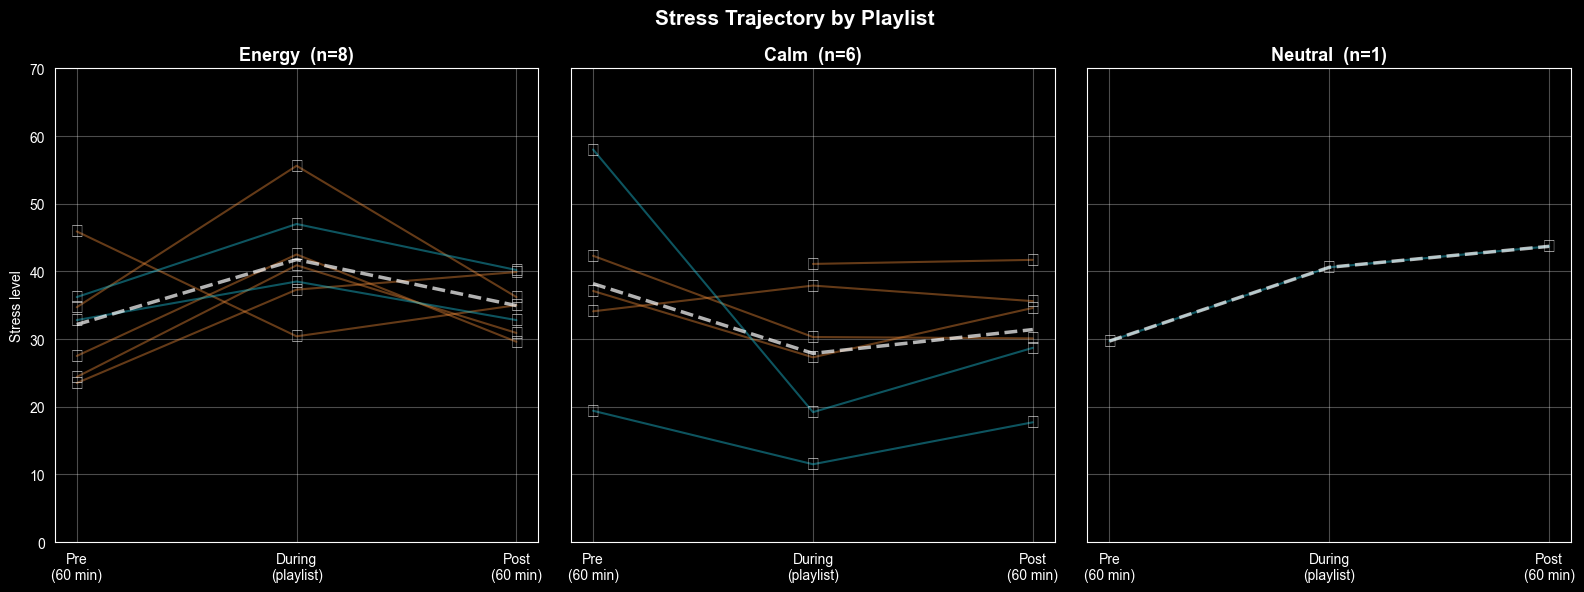

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
playlists = [p for p in ["Energy", "Calm", "Neutral"] if p in sessions["playlist"].values]

for ax, pl in zip(axes, playlists + ["_pad"] * (3 - len(playlists))):
    if pl == "_pad":
        ax.axis("off"); continue
    sub = sessions[sessions["playlist"] == pl]

    for _, r in sub.iterrows():
        clr = PARTICIPANTS[r["participant"]]["color"]
        xs = [0, 1, 2]
        ys = [r["pre_stress_mean"], r["stress_mean"], r["post_stress_mean"]]
        ax.plot(xs, ys, color=clr, alpha=0.4, lw=1.5)
        for x, y in zip(xs, ys):
            if pd.notna(y):
                ax.text(x, y, r["emoji"], fontsize=14, ha="center", va="center")

    # Mean line
    means = [sub["pre_stress_mean"].mean(), sub["stress_mean"].mean(), sub["post_stress_mean"].mean()]
    ax.plot([0, 1, 2], means, color="white", lw=2.5, ls="--", alpha=0.7, zorder=10)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Pre\n(60 min)", "During\n(playlist)", "Post\n(60 min)"])
    ax.set_title(f"{pl}  (n={len(sub)})", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 70)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Stress level")
plt.suptitle("Stress Trajectory by Playlist", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Average minute-level trace by playlist

Mean stress over time across all participants, per playlist type.  
Shaded band = ±1 standard deviation.

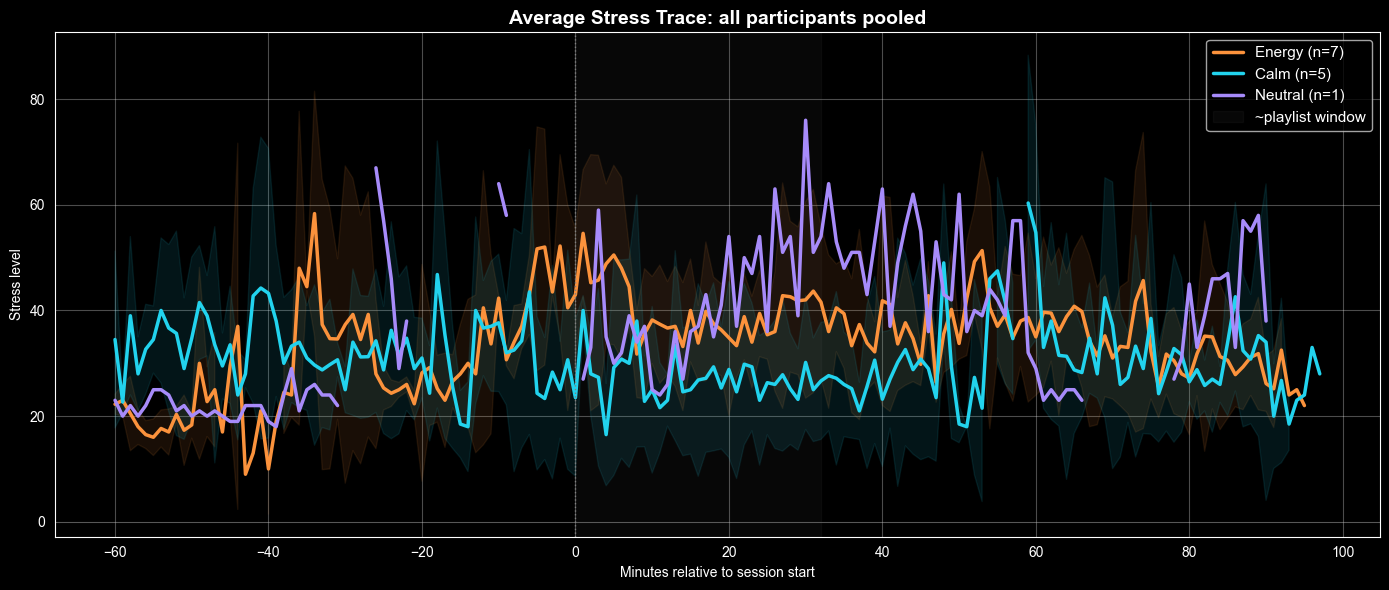

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

palette = {"Energy": "#fb923c", "Calm": "#22d3ee", "Neutral": "#a78bfa"}
for pl, color in palette.items():
    sub = traces[traces["playlist"] == pl]
    if sub.empty:
        continue
    grouped = sub.groupby("minutes_relative")["stress"]
    mean = grouped.mean()
    std = grouped.std()
    ax.plot(mean.index, mean.values, color=color, lw=2.5, label=f"{pl} (n={sub['session_date'].nunique()})")
    ax.fill_between(mean.index, mean - std, mean + std, color=color, alpha=0.1)

ax.axvline(0, color="grey", ls=":", lw=1)
ax.axvspan(0, 32, alpha=0.06, color="grey", label="~playlist window")
ax.axhline(0, color="grey", lw=0.5, alpha=0.3)
ax.set_xlabel("Minutes relative to session start")
ax.set_ylabel("Stress level")
ax.set_title("Average Stress Trace: all participants pooled", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Deviation from baseline (time-of-day adjusted)

For each session, how much does during-session stress differ from what this  
participant *normally* experiences at that time of day on non-session days?  

This is the strongest metric — it controls for circadian rhythm and individual differences.

/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3601482354.py:61: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3601482354.py:61: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  plt.tight_layout()
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


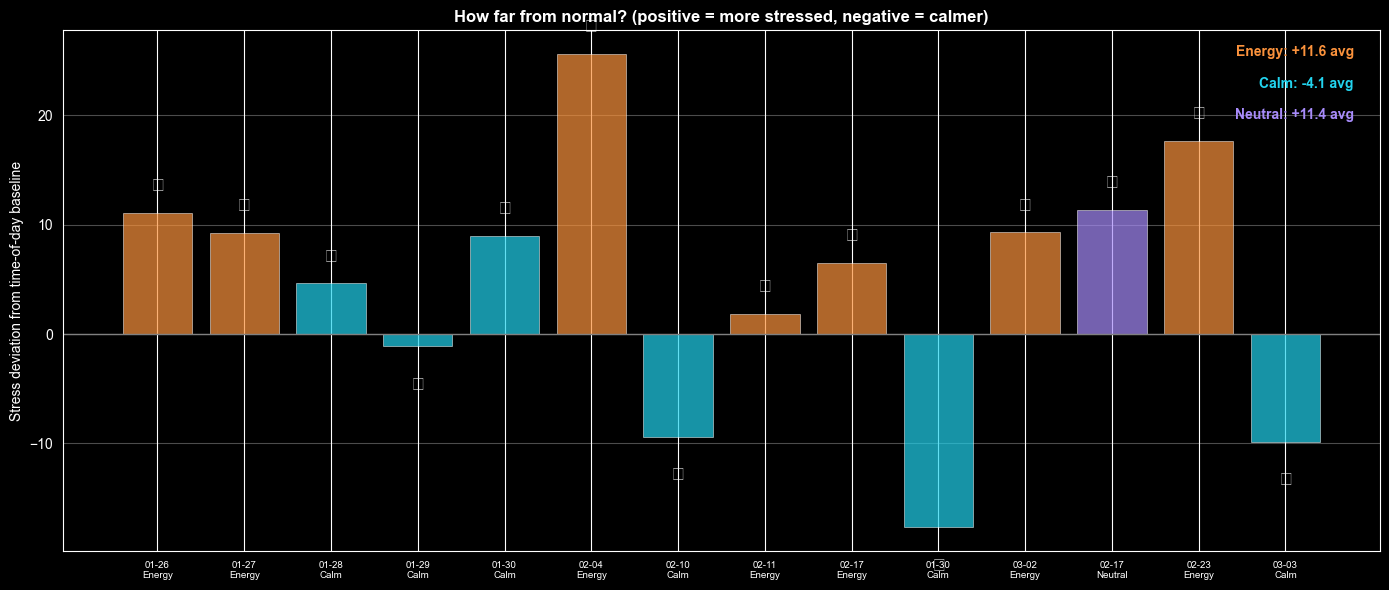

In [22]:
# Compute per-participant, per-minute baseline from non-session days
non_session_bl = baselines[~baselines["is_session"]].copy()
non_session_bl["minute_of_day"] = (non_session_bl["timestamp"].dt.hour * 60 +
                                    non_session_bl["timestamp"].dt.minute)

deviations = []
for _, r in sessions.iterrows():
    # Get participant's baseline
    pbl = non_session_bl[non_session_bl["participant"] == r["participant"]]
    bl_by_min = pbl.groupby("minute_of_day")["stress"].mean()

    # Get this session's during-phase trace
    t = traces[(traces["session_date"] == r["date"]) &
               (traces["participant"] == r["participant"]) &
               (traces["phase"] == "during")].copy()
    if t.empty:
        continue
    t_utc = pd.to_datetime(t["timestamp_utc"])
    t["mod"] = t_utc.dt.hour * 60 + t_utc.dt.minute
    matched_bl = t["mod"].map(bl_by_min)

    if t["stress"].notna().any() and matched_bl.notna().any():
        deviations.append({
            "participant": r["participant"],
            "emoji": r["emoji"],
            "date": r["date"],
            "playlist": r["playlist"],
            "session_stress": t["stress"].mean(),
            "baseline_stress": matched_bl.mean(),
            "deviation": t["stress"].mean() - matched_bl.mean(),
        })

dev = pd.DataFrame(deviations)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(dev))
palette = {"Energy": "#fb923c", "Calm": "#22d3ee", "Neutral": "#a78bfa"}
colors = [palette.get(p, "grey") for p in dev["playlist"]]
bars = ax.bar(x, dev["deviation"], color=colors, alpha=0.7, edgecolor="white", lw=0.5)

# Emoji labels
for i, (_, r) in enumerate(dev.iterrows()):
    y = r["deviation"]
    ax.text(i, y + (2 if y >= 0 else -4), r["emoji"], ha="center", fontsize=14)

ax.axhline(0, color="grey", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['date'][5:]}\n{r['playlist']}" for _, r in dev.iterrows()], fontsize=7)
ax.set_ylabel("Stress deviation from time-of-day baseline")
ax.set_title("How far from normal? (positive = more stressed, negative = calmer)", fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

# Summary
for pl in ["Energy", "Calm", "Neutral"]:
    sub = dev[dev["playlist"] == pl]
    if len(sub):
        avg = sub["deviation"].mean()
        ax.annotate(f"{pl}: {avg:+.1f} avg", xy=(0.98, 0.95 - list(palette.keys()).index(pl) * 0.06),
                    xycoords="axes fraction", ha="right", fontsize=10, color=palette[pl], fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Mood change vs stress change

Does the objective physiological shift predict the subjective mood report?

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (x_col, xlabel) in zip(axes, [
    ("stress_delta", "Stress Δ (post 60min − pre 60min)"),
    ("deviation", "Stress deviation from baseline"),
]):
    if x_col == "deviation":
        plot_df = sessions.merge(dev[["participant", "date", "deviation"]], on=["participant", "date"], how="left")
    else:
        plot_df = sessions

    for _, r in plot_df.iterrows():
        xv = r.get(x_col)
        if pd.isna(xv) or pd.isna(r["mood_delta"]):
            continue
        clr = PARTICIPANTS.get(r["participant"], {}).get("color", "grey")
        ax.text(xv, r["mood_delta"], r["emoji"], fontsize=16, ha="center", va="center")

    # Quadrant labels
    ax.axhline(0, color="grey", ls=":", lw=0.8)
    ax.axvline(0, color="grey", ls=":", lw=0.8)
    ax.text(0.02, 0.98, "↓ stress, ↑ mood\n(ideal for Calm)", transform=ax.transAxes,
            fontsize=8, color="#22d3ee", va="top", alpha=0.7)
    ax.text(0.98, 0.02, "↑ stress, ↓ mood\n(over-activation?)", transform=ax.transAxes,
            fontsize=8, color="#f87171", ha="right", alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mood Δ (after − before)")
    ax.grid(True, alpha=0.3)

axes[0].set_title("Mood vs Pre→Post Stress Change", fontweight="bold")
axes[1].set_title("Mood vs Baseline Deviation", fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1933439813.py:32: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1933439813.py:32: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1933439813.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  fig.canvas.print_fi

## 6. Per-participant × playlist summary

Aggregated stats for each participant, split by playlist type.

In [24]:
summary = sessions.groupby(["emoji", "participant", "playlist"]).agg(
    n=("date", "count"),
    stress_pre=("pre_stress_mean", "mean"),
    stress_dur=("stress_mean", "mean"),
    stress_post=("post_stress_mean", "mean"),
    stress_delta=("stress_delta", "mean"),
    mood_delta=("mood_delta", "mean"),
    hr_mean=("hr_mean", "mean"),
).round(1)

summary

n  stress_pre  stress_dur  stress_post  \
emoji participant playlist                                           
🍋     limoen      Energy    1         NaN         NaN          NaN   
🥥     kokosnoot   Calm      4        37.8        34.2         35.5   
                  Energy    5        31.2        41.3         34.3   
🫐     bosbes      Calm      2        38.7        15.4         23.2   
                  Energy    2        34.5        42.8         36.5   
                  Neutral   1        29.7        40.6         43.7   

                            stress_delta  mood_delta  hr_mean  
emoji participant playlist                                     
🍋     limoen      Energy             NaN        -1.0     77.3  
🥥     kokosnoot   Calm              -4.4         1.8     81.2  
                  Energy             3.1         0.2     86.9  
🫐     bosbes      Calm             -15.5        -1.0     63.7  
                  Energy             2.0         0.5     86.0  
                  Neutral           14.0         2.0      NaN

## 7. Pooled recovery curve (baseline-normalised)

All sessions normalised to their pre-session stress baseline (0 = normal).  
Thick lines = mean per playlist type across all participants.

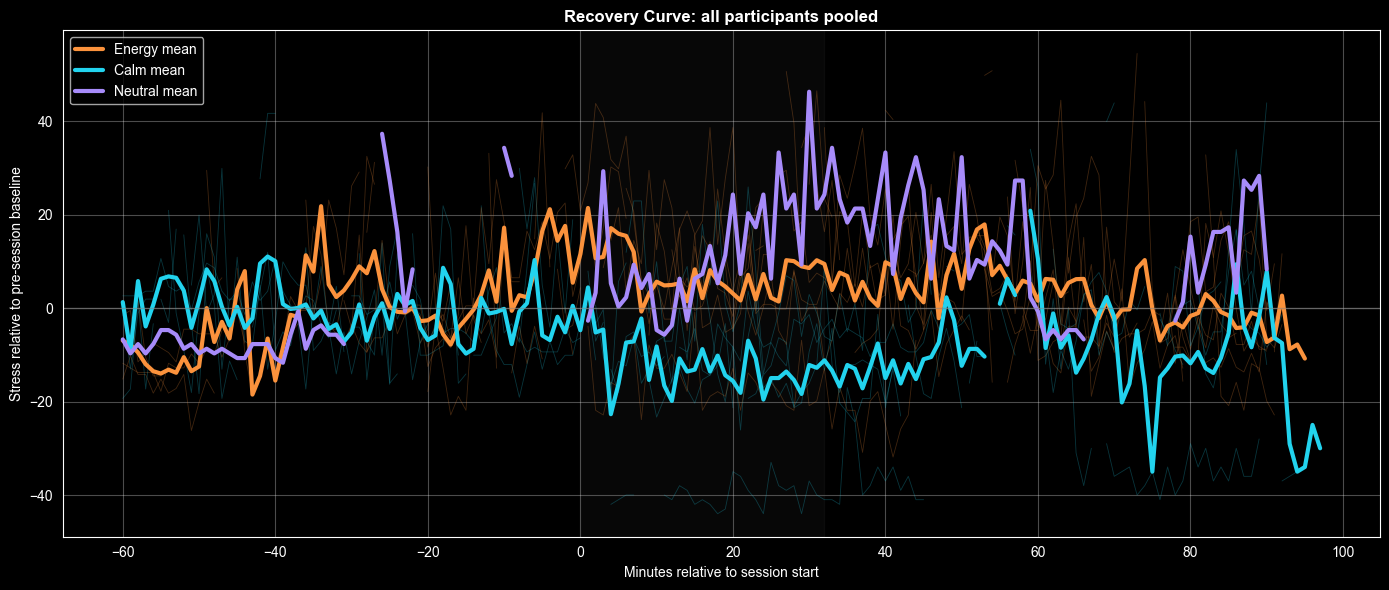

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

normed_traces = []
for (participant, date), group in traces.groupby(["participant", "session_date"]):
    pre = group[group["phase"] == "pre"]["stress"].mean()
    if np.isnan(pre):
        continue
    g = group.copy()
    g["stress_norm"] = g["stress"] - pre
    normed_traces.append(g)

if normed_traces:
    normed = pd.concat(normed_traces)

    # Individual traces (thin)
    for (participant, date), g in normed.groupby(["participant", "session_date"]):
        pl = g["playlist"].iloc[0]
        clr = palette.get(pl, "grey")
        ax.plot(g["minutes_relative"], g["stress_norm"], color=clr, lw=0.6, alpha=0.25)

    # Mean per playlist (thick)
    for pl, color in palette.items():
        sub = normed[normed["playlist"] == pl]
        if sub.empty:
            continue
        mean = sub.groupby("minutes_relative")["stress_norm"].mean()
        ax.plot(mean.index, mean.values, color=color, lw=3, label=f"{pl} mean")

ax.axhline(0, color="grey", ls="-", lw=1, alpha=0.5)
ax.axvspan(0, 32, alpha=0.06, color="grey")
ax.set_xlabel("Minutes relative to session start")
ax.set_ylabel("Stress relative to pre-session baseline")
ax.set_title("Recovery Curve: all participants pooled", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Heatmap: all sessions across all participants

Each row = one session. Colour = stress level per minute.  
Sorted by playlist type, then participant.

/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3965950372.py:31: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3965950372.py:31: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/3965950372.py:31: UserWarning: Glyph 127819 (\N{LEMON}) missing from font(s) Arial.
  plt.tight_layout()
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.ven

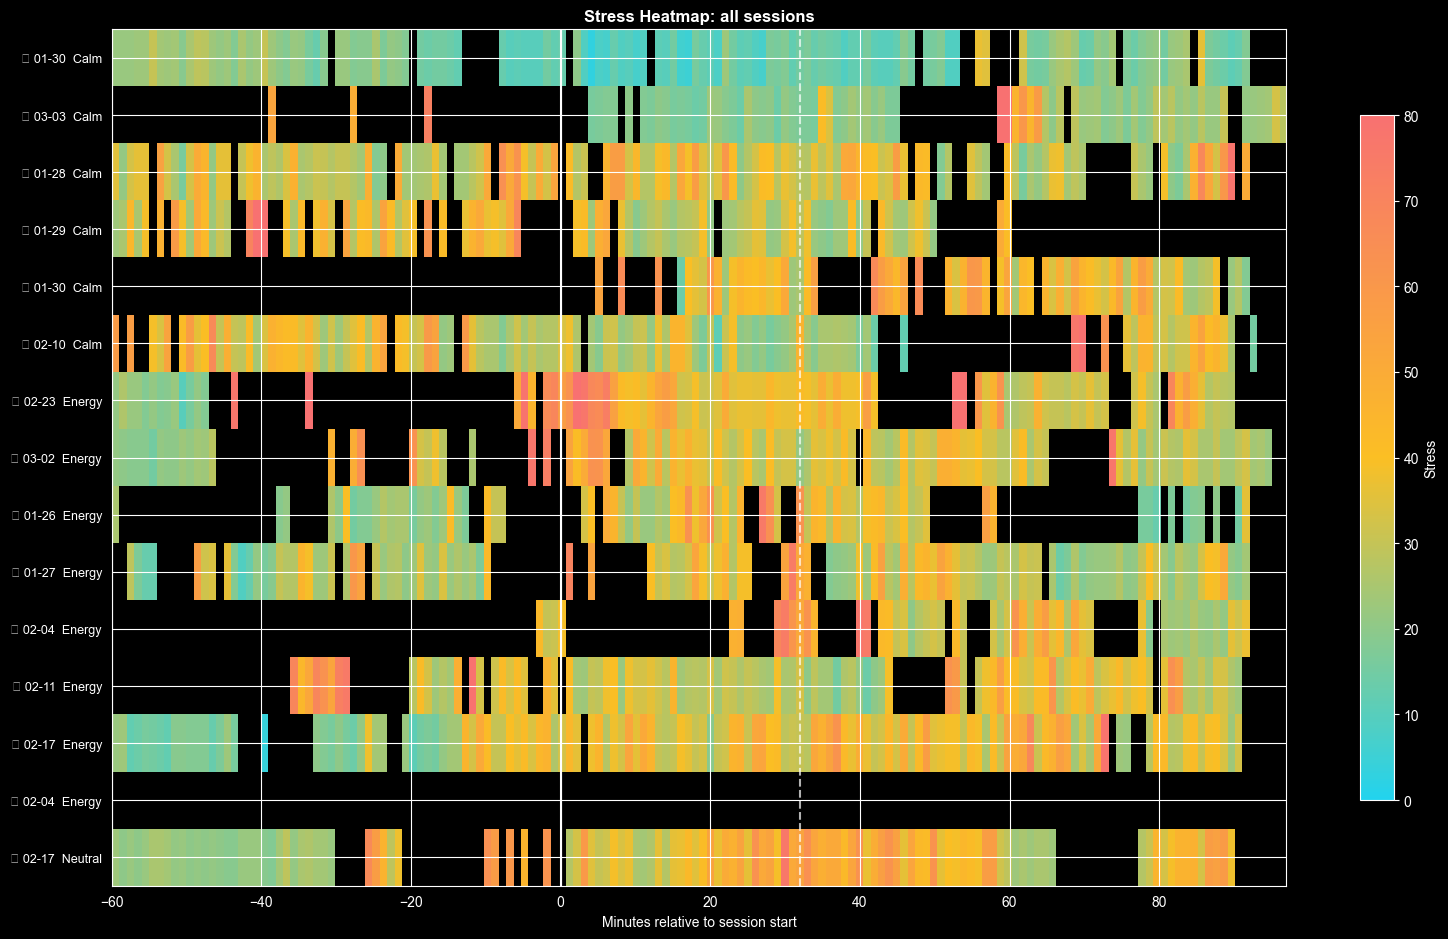

In [26]:
import matplotlib.colors as mcolors

sorted_sessions = sessions.sort_values(["playlist", "participant", "date"])

all_minutes = sorted(traces["minutes_relative"].unique())
matrix = []
ylabels = []

for _, r in sorted_sessions.iterrows():
    t = traces[(traces["session_date"] == r["date"]) &
               (traces["participant"] == r["participant"])]
    if t.empty:
        continue
    row = t.set_index("minutes_relative")["stress"].reindex(all_minutes)
    matrix.append(row.values)
    ylabels.append(f"{r['emoji']} {r['date'][5:]}  {r['playlist']}")

if matrix:
    matrix = np.array(matrix)
    fig, ax = plt.subplots(figsize=(16, 0.5 * len(matrix) + 2))
    cmap = mcolors.LinearSegmentedColormap.from_list("stress", ["#22d3ee", "#fbbf24", "#f87171"])
    im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=80,
                   extent=[min(all_minutes), max(all_minutes), len(matrix) - 0.5, -0.5])
    ax.axvline(0, color="white", lw=1.5)
    ax.axvline(32, color="white", lw=1.5, ls="--", alpha=0.7)
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel("Minutes relative to session start")
    ax.set_title("Stress Heatmap: all sessions", fontweight="bold")
    plt.colorbar(im, ax=ax, label="Stress", shrink=0.8)
    plt.tight_layout()
    plt.show()

## 9. Circadian profiles: session vs non-session days

Each participant's typical hourly stress on non-session days,  
with session data points overlaid.

/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1311552888.py:33: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1311552888.py:33: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_53898/1311552888.py:33: UserWarning: Glyph 127819 (\N{LEMON}) missing from font(s) Arial.
  plt.tight_layout()
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129381 (\N{COCONUT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129744 (\N{BLUEBERRIES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/timothydhoe/Code/spotify-project/.ven

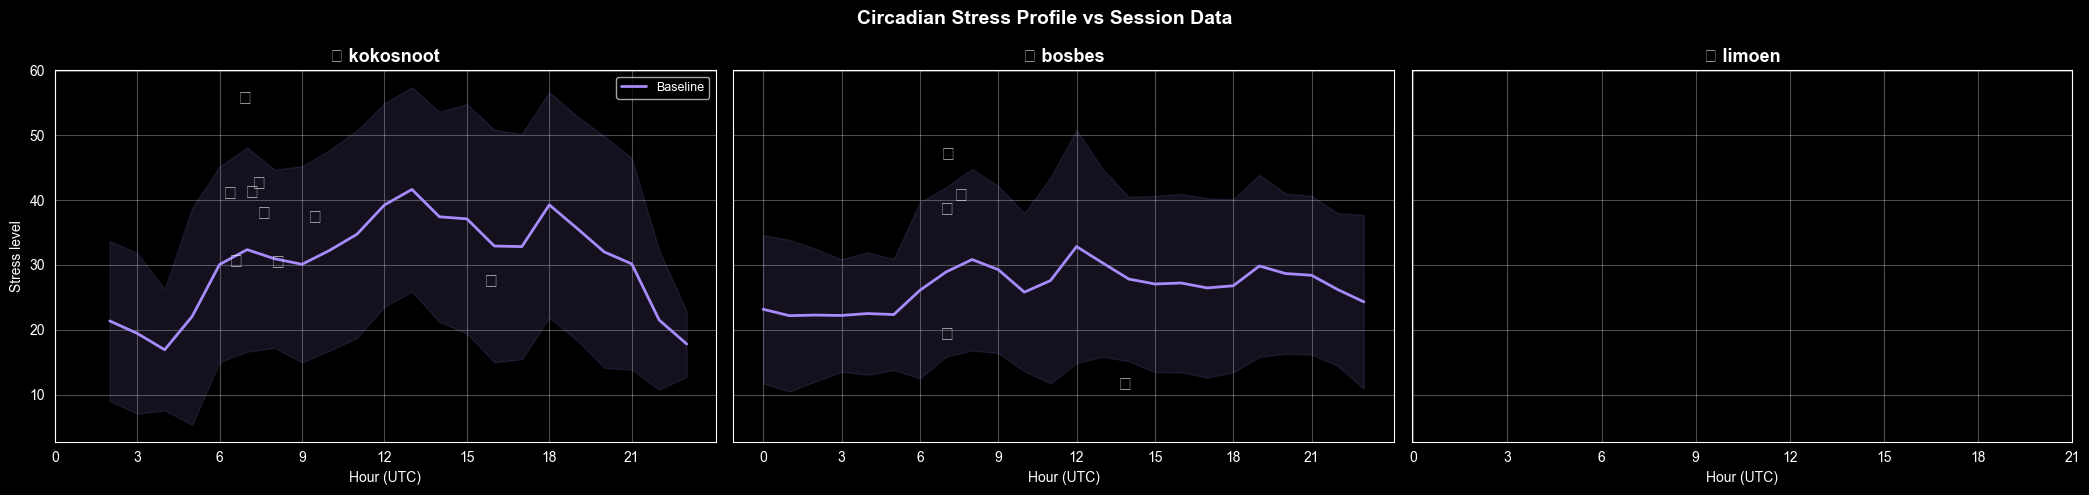

In [27]:
n_participants = len(PARTICIPANTS)
fig, axes = plt.subplots(1, n_participants, figsize=(7 * n_participants, 5), sharey=True)
if n_participants == 1:
    axes = [axes]

for ax, (name, meta) in zip(axes, PARTICIPANTS.items()):
    pbl = baselines[(baselines["participant"] == name) & (~baselines["is_session"])]
    hourly = pbl.groupby("hour_utc")["stress"].agg(["mean", "std", "count"])
    hourly = hourly[hourly["count"] >= 10]

    ax.plot(hourly.index, hourly["mean"], color="#a78bfa", lw=2, label="Baseline")
    ax.fill_between(hourly.index, hourly["mean"] - hourly["std"],
                    hourly["mean"] + hourly["std"], color="#a78bfa", alpha=0.12)

    # Overlay sessions
    psess = sessions[sessions["participant"] == name]
    for _, r in psess.iterrows():
        h, m = map(int, r["start_local"].split(":"))
        utc_h = h - 1  # CET → UTC
        pl = r["playlist"]
        clr = palette.get(pl, "grey")
        ax.text(utc_h + m/60, r["stress_mean"], meta["emoji"], fontsize=14, ha="center", va="center", zorder=5)

    ax.set_title(f"{meta['emoji']} {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour (UTC)")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Stress level")
        ax.legend(fontsize=9)

plt.suptitle("Circadian Stress Profile vs Session Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Key findings

Auto-generated summary statistics across all participants.

In [28]:
print("=" * 60)
print("CROSS-PARTICIPANT SUMMARY")
print("=" * 60)

for pl in ["Energy", "Calm", "Neutral"]:
    sub = sessions[sessions["playlist"] == pl]
    if sub.empty:
        continue
    d = sub["stress_delta"].dropna()
    m = sub["mood_delta"].dropna()
    print(f"\n{pl} (n={len(sub)} sessions, {sub['participant'].nunique()} participants)")
    print(f"  Stress: pre {sub['pre_stress_mean'].mean():.1f} → "
          f"during {sub['stress_mean'].mean():.1f} → "
          f"post {sub['post_stress_mean'].mean():.1f}")
    if len(d):
        print(f"  Stress delta: {d.mean():+.1f} (range {d.min():+.1f} to {d.max():+.1f})")
    print(f"  Mood delta: {m.mean():+.1f} (range {m.min():+.0f} to {m.max():+.0f})")
    if sub["hr_mean"].notna().any():
        print(f"  HR during: {sub['hr_mean'].dropna().mean():.0f} bpm")

# Baseline deviations
if len(dev):
    print(f"\nBaseline deviations (vs time-of-day normal):")
    for pl in ["Energy", "Calm", "Neutral"]:
        sub = dev[dev["playlist"] == pl]
        if len(sub):
            print(f"  {pl}: {sub['deviation'].mean():+.1f} "
                  f"(per participant: {sub.groupby('participant')['deviation'].mean().to_dict()})")

# Correlations
print(f"\nCorrelations (all sessions):")
valid = sessions.dropna(subset=["stress_delta", "mood_delta"])
if len(valid) >= 5:
    r = valid["stress_delta"].corr(valid["mood_delta"])
    print(f"  Stress delta ↔ Mood delta: r = {r:.2f} (n={len(valid)})")

print(f"\n{'='*60}")
print(f"Total: {len(sessions)} sessions across {sessions['participant'].nunique()} participants")
print(f"{'='*60}")

CROSS-PARTICIPANT SUMMARY

Energy (n=8 sessions, 3 participants)
  Stress: pre 32.1 → during 41.7 → post 34.9
  Stress delta: +2.8 (range -10.9 to +16.4)
  Mood delta: +0.1 (range -2 to +2)
  HR during: 85 bpm

Calm (n=6 sessions, 2 participants)
  Stress: pre 38.2 → during 27.9 → post 31.4
  Stress delta: -8.9 (range -29.3 to +1.5)
  Mood delta: +0.8 (range -1 to +4)
  HR during: 74 bpm

Neutral (n=1 sessions, 1 participants)
  Stress: pre 29.7 → during 40.6 → post 43.7
  Stress delta: +14.0 (range +14.0 to +14.0)
  Mood delta: +2.0 (range +2 to +2)

Baseline deviations (vs time-of-day normal):
  Energy: +11.6 (per participant: {'bosbes': 13.47924555137477, 'kokosnoot': 10.873915648711002})
  Calm: -4.1 (per participant: {'bosbes': -13.739944804958077, 'kokosnoot': 0.7857160740060154})
  Neutral: +11.4 (per participant: {'bosbes': 11.360331750314224})

Correlations (all sessions):
  Stress delta ↔ Mood delta: r = 0.04 (n=13)

Total: 15 sessions across 3 participants
